In [17]:
import wfdb
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy import signal


def plot_ecg_preview(signal_values, record_name, plot_samples=1000):
    """
    Plot a preview of an ECG waveform using the first plot_samples points.
    """
    # Ensure we never request more points than available in the signal.
    plot_samples = min(int(plot_samples), len(signal_values))
    print(f"Plotting the first {plot_samples} samples for visualization...")

    plt.figure(figsize=(12, 4))
    plt.plot(signal_values[:plot_samples], color='red', linewidth=1.5)
    plt.title(f"Normalized ECG Waveform Preview (Record {record_name}, Lead MLII)")
    plt.xlabel("Sample Number")
    plt.ylabel("Normalized Voltage [0, 1]")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


def normalize_recordwise_percentile_minmax(signal_series):
    """
    Offline normalization using full-record percentiles and min-max scaling.
    """
    # Robustly estimate lower/upper bounds from the full record.
    p_low = signal_series.quantile(0.005)
    p_high = signal_series.quantile(0.999)

    # Remove extreme outliers before min-max scaling.
    clipped = signal_series.clip(lower=p_low, upper=p_high)
    min_val = clipped.min()
    max_val = clipped.max()

    # Normalize to [0, 1]; handle flat signals safely.
    if max_val > min_val:
        normalized = (clipped - min_val) / (max_val - min_val)
    else:
        print("Warning: Flat signal after clipping; setting normalized values to 0.0")
        normalized = pd.Series(np.zeros(len(clipped)), index=clipped.index)

    stats = {
        "mode": "record",
        "p_low": float(p_low),
        "p_high": float(p_high),
        "min_val": float(min_val),
        "max_val": float(max_val),
    }
    return normalized, stats


def normalize_online_robust(signal_series, fs, window_sec=10, clip_z=5.0, eps=1e-6):
    """
    Causal/online-like normalization using trailing median and trailing MAD.
    Output is mapped to [0, 1].
    """
    # Convert window duration to number of samples.
    window_samples = max(1, int(window_sec * fs))

    # Estimate baseline from trailing median and remove it.
    baseline = signal_series.rolling(window=window_samples, min_periods=1).median()
    detrended = signal_series - baseline

    # Estimate robust scale using trailing MAD.
    mad = detrended.abs().rolling(window=window_samples, min_periods=1).median()
    robust_scale = 1.4826 * mad  # Converts MAD to sigma-like scale for Gaussian assumptions.
    robust_scale = robust_scale.clip(lower=eps)  # Avoid division by zero.

    # Robust z-score, then clip outliers.
    z = detrended / robust_scale
    z_clipped = z.clip(lower=-clip_z, upper=clip_z)

    # Map clipped z-score from [-clip_z, +clip_z] to [0, 1].
    normalized = (z_clipped + clip_z) / (2 * clip_z)

    stats = {
        "mode": "online",
        "window_sec": float(window_sec),
        "window_samples": int(window_samples),
        "clip_z": float(clip_z),
    }
    return normalized, stats



def convert_and_normalize_mitdb(
    record_name,
    dataset_dir,
    output_filename,
    plot_samples=1000,
    target_fs=125,
    normalization_mode="record",
    online_window_sec=10,
    online_clip_z=5.0,
):
    """
    Reads a local MIT-BIH record, extracts the MLII lead,
    resamples it to target_fs, normalizes it, saves it as a CSV, and plots a preview.

    normalization_mode:
      - "record": full-record percentile clip + min-max (offline)
      - "online": trailing median/MAD robust normalization (causal-like)
    """
    # Validate local dataset path.
    if not dataset_dir:
        raise ValueError("dataset_dir is required and must point to your local MIT-BIH folder")
    if not os.path.isdir(dataset_dir):
        raise FileNotFoundError(f"Local dataset_dir not found: {dataset_dir}")

    # Read the selected record from local WFDB files.
    record_base = os.path.join(dataset_dir, record_name)
    print(f"Loading local record: {record_base}")
    record = wfdb.rdrecord(record_base)

    # Build DataFrame with named leads.
    df = pd.DataFrame(record.p_signal, columns=record.sig_name)

    # Keep only MLII for single-lead pipeline.
    if 'MLII' not in df.columns:
        print(f"Error: 'MLII' lead not found in record {record_name}.")
        print(f"Available leads for this record are: {record.sig_name}")
        return
    df_mlii = df[['MLII']].copy()

    # Resample to target sampling rate.
    original_fs = record.fs
    if original_fs != target_fs:
        print(f"Resampling from {original_fs}Hz to {target_fs}Hz...")
        new_length = int(len(df_mlii) * target_fs / original_fs)
        resampled_signal = signal.resample(df_mlii['MLII'], new_length)
        df_mlii = pd.DataFrame({'MLII': resampled_signal})

        # Keep plot duration approximately equivalent in seconds.
        plot_samples = int(plot_samples * target_fs / original_fs)

    # Select normalization strategy.
    if normalization_mode == "record":
        normalized, norm_stats = normalize_recordwise_percentile_minmax(df_mlii['MLII'])
    elif normalization_mode == "online":
        normalized, norm_stats = normalize_online_robust(
            df_mlii['MLII'],
            fs=target_fs,
            window_sec=online_window_sec,
            clip_z=online_clip_z,
        )
    else:
        raise ValueError("normalization_mode must be 'record' or 'online'")

    # Replace MLII column with normalized values and save.
    df_mlii['MLII'] = normalized
    df_mlii.to_csv(output_filename, index=False)

    # Print normalization summary.
    print(f"Successfully saved normalized MLII from {record_name} to {output_filename}!")
    print(f"Normalization mode: {norm_stats['mode']}")
    if norm_stats['mode'] == 'record':
        print(f"Clip Range (mV): [{norm_stats['p_low']:.3f}, {norm_stats['p_high']:.3f}]")
    else:
        print(f"Online window: {norm_stats['window_sec']} sec ({norm_stats['window_samples']} samples)")
        print(f"Online clip z: ±{norm_stats['clip_z']}")
    print(f"Output Range: [{df_mlii['MLII'].min():.3f}, {df_mlii['MLII'].max():.3f}]")

    # Visual sanity check.
    plot_ecg_preview(df_mlii['MLII'].to_numpy(), record_name=record_name, plot_samples=plot_samples)


def find_and_extract_mixed_snippets(output_dir="mixed_snippets", snippet_duration_min=2, target_fs=125):
    """
    Searches the MIT-BIH database for ~2-minute snippets containing a mix of different
    heartbeat classes, resamples to target_fs, normalizes the MLII lead, and saves them to CSV.
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    print(f"Searching for {snippet_duration_min}-minute snippets with diverse heartbeats...")

    fs = 360 # Standard sampling frequency for MIT-BIH
    snippet_samples = snippet_duration_min * 60 * fs

    # A curated list of records from MIT-BIH known to contain various arrhythmias
    # 109 = LBBB, 118 = RBBB, 119 = PVCs, 200 = Ventricular bigeminy, etc.
    records_to_check = ['100', '109', '111', '118', '119', '200', '207', '212', '213', '214', '232']

    # Mapping standard MIT-BIH annotation symbols to your project's beat-level classes:
    # 'N': Normal
    # 'L': LBBB
    # 'R': RBBB
    # 'V': PVC
    # 'A': Atrial premature beat (used here as 'Abnormal')

    target_symbols = {'N', 'L', 'R', 'V', 'A'}

    # Keep track of which classes we've successfully found a snippet for
    classes_found = set()
    snippet_count = 0

    for record_name in records_to_check:
        # Stop if we've found all possible beat-level targets
        if target_symbols.issubset(classes_found):
            break

        try:
            # Read annotations and signal directly from PhysioNet
            ann = wfdb.rdann(record_name, 'atr', pn_dir='mitdb')
            record = wfdb.rdrecord(record_name, pn_dir='mitdb')
        except Exception as e:
            print(f"Could not load record {record_name}: {e}")
            continue

        # Create a Pandas DataFrame for the signal
        df = pd.DataFrame(record.p_signal, columns=record.sig_name)
        if 'MLII' not in df.columns:
            continue

        total_samples = record.sig_len

        # Slide a window across the record to find interesting snippets
        for start_idx in range(0, total_samples - snippet_samples, snippet_samples):
            end_idx = start_idx + snippet_samples

            # Find annotations that fall exactly within this 2-minute window
            window_mask = (ann.sample >= start_idx) & (ann.sample < end_idx)
            window_symbols = set(np.array(ann.symbol)[window_mask])

            # Check which of our target symbols are present in this window
            present_targets = window_symbols.intersection(target_symbols)

            # Identify if this snippet contains any classes we haven't found yet
            new_classes_found = present_targets - classes_found

            # If this snippet has a good mix (at least 2 types) AND brings us a new class
            if len(present_targets) >= 2 and len(new_classes_found) > 0:
                classes_found.update(present_targets)
                snippet_count += 1

                # Extract the MLII signal for this specific timeframe
                df_snippet = df[['MLII']].iloc[start_idx:end_idx].copy()

                # Resample the signal down to target_fs
                if fs != target_fs:
                    new_length = int(len(df_snippet) * target_fs / fs)
                    resampled_signal = signal.resample(df_snippet['MLII'], new_length)
                    df_snippet = pd.DataFrame({'MLII': resampled_signal})

                # Normalize using percentile clipping (0.5% and 99.5%) to ignore static/noise spikes
                p_low = df_snippet['MLII'].quantile(0.005)
                p_high = df_snippet['MLII'].quantile(0.995)
                df_snippet['MLII'] = df_snippet['MLII'].clip(lower=p_low, upper=p_high)

                min_val = df_snippet['MLII'].min()
                max_val = df_snippet['MLII'].max()

                if max_val > min_val: # Safety check to avoid division by zero
                    df_snippet['MLII'] = (df_snippet['MLII'] - min_val) / (max_val - min_val)

                # Format the filename based on the beat types found
                classes_str = "_".join(sorted(list(present_targets)))
                minute_mark = start_idx // (60 * fs)
                output_filename = os.path.join(output_dir, f"rec_{record_name}_min_{minute_mark}_{classes_str}.csv")

                # Save to CSV
                df_snippet.to_csv(output_filename, index=False)

                # Calculate and format the timestamps (MM:SS)
                start_time_sec = start_idx / fs
                end_time_sec = end_idx / fs
                start_m, start_s = divmod(int(start_time_sec), 60)
                end_m, end_s = divmod(int(end_time_sec), 60)

                print(f"Saved Snippet {snippet_count}: {output_filename}")
                print(f"  -> Timeframe: {start_m:02d}:{start_s:02d} to {end_m:02d}:{end_s:02d}")
                print(f"  -> Contained target beats: {present_targets}")

                # Break to move to the next record so our snippets are diverse across patients
                break

    print(f"\nFinished extraction!")
    print(f"Successfully captured snippets containing these target beat classes: {classes_found}")


# Example usage 1: Convert a single entire record (30 mins)
# local_dataset_dir = r"C:\datasets\mit-bih-arrhythmia-database-1.0.0"
# target_record = '100'
# output_file_record_mode = 'record_100_mlii_norm_record.csv'
# output_file_online_mode = 'record_100_mlii_norm_online.csv'
# convert_and_normalize_mitdb(target_record, local_dataset_dir, output_file_record_mode, normalization_mode='record')
# convert_and_normalize_mitdb(target_record, local_dataset_dir, output_file_online_mode, normalization_mode='online', online_window_sec=10, online_clip_z=5.0)

# Example usage 2: Hunt for 2-minute snippets with varied heartbeats
#find_and_extract_mixed_snippets(output_dir="mixed_ecg_snippets", snippet_duration_min=2)

In [18]:
import os
import wfdb
import pandas as pd
import numpy as np

# Annotation pipeline for all MIT-BIH records (sample-aligned to 125 Hz)
# Local dataset path is required (no download mode).

CLASS_MAP = {
    'N': 'N',  # Normal beat
    'L': 'L',  # Left bundle branch block beat
    'R': 'R',  # Right bundle branch block beat
    'V': 'V',  # Premature ventricular contraction
    'F': 'F',  # Fusion of ventricular and normal beat
    '/': '/',  # Paced beat
    'A': 'A',  # Atrial premature beat
}


def map_symbol(symbol: str) -> str:
    return CLASS_MAP.get(symbol, 'OTHER')


def _safe_attr_list(obj, attr_name, length, default_value):
    """Helper to extract optional WFDB fields."""
    values = getattr(obj, attr_name, None)
    if values is None:
        return [default_value] * length

    values = list(values)
    if len(values) < length:
        values.extend([default_value] * (length - len(values)))
    elif len(values) > length:
        values = values[:length]
    return values


def _validate_local_dataset_dir(dataset_dir):
    if not dataset_dir:
        raise ValueError("dataset_dir is required and must point to your local MIT-BIH folder")
    if not os.path.isdir(dataset_dir):
        raise FileNotFoundError(f"Local dataset_dir not found: {dataset_dir}")


def _list_local_records(dataset_dir):
    dat_files = [f for f in os.listdir(dataset_dir) if f.lower().endswith('.dat')]
    records = sorted({os.path.splitext(f)[0] for f in dat_files})
    if not records:
        raise FileNotFoundError(f"No .dat files found in local dataset_dir: {dataset_dir}")
    return records


def _read_record_and_ann_local(record_name, dataset_dir):
    record_base = os.path.join(dataset_dir, record_name)
    record = wfdb.rdrecord(record_base)
    ann = wfdb.rdann(record_base, "atr")
    return record, ann


def build_annotations_for_record(
    record_name,
    dataset_dir,
    out_dir="dataset_125hz/annotations",
    target_fs=125,
):
    _validate_local_dataset_dir(dataset_dir)
    record, ann = _read_record_and_ann_local(record_name, dataset_dir)

    original_fs = float(record.fs)
    ratio = target_fs / original_fs
    signal_len_original = int(record.sig_len)
    signal_len_target = int(np.rint(signal_len_original * ratio))

    ann_original = np.asarray(ann.sample, dtype=np.int64)
    ann_target = np.rint(ann_original * ratio).astype(np.int64)
    ann_target = np.clip(ann_target, 0, max(signal_len_target - 1, 0))

    symbols = list(ann.symbol)
    rhythm = _safe_attr_list(ann, "aux_note", len(symbols), "")
    
    # Map symbols to classes: '+' becomes 'RHYTHM', others map normally
    mapped_classes = [
        'RHYTHM' if s == '+' else map_symbol(s) 
        for s in symbols
    ]

    df_ann = pd.DataFrame({
        "record_id": record_name,
        "sample_original": ann_original,
        "sample_125": ann_target,
        "time_sec_original": ann_original / original_fs,
        "time_sec_125": ann_target / target_fs,
        "symbol": symbols,
        "mapped_class": mapped_classes,
        "rhythm": rhythm,
    })

    df_ann = df_ann.sort_values(["sample_125", "sample_original"]).reset_index(drop=True)

    os.makedirs(out_dir, exist_ok=True)
    output_file = os.path.join(out_dir, f"{record_name}_annotations_125hz.csv")
    df_ann.to_csv(output_file, index=False)

    return {
        "record_id": record_name,
        "fs_original": original_fs,
        "fs_target": target_fs,
        "signal_len_original": signal_len_original,
        "signal_len_target": signal_len_target,
        "n_annotations": int(len(df_ann)),
        "n_target_classes": int((df_ann["mapped_class"] != "OTHER").sum()),
        "output_file": output_file,
    }


def build_all_mitbih_annotations(
    dataset_dir,
    out_root="dataset_125hz",
    target_fs=125,
):
    _validate_local_dataset_dir(dataset_dir)

    ann_dir = os.path.join(out_root, "annotations")
    os.makedirs(ann_dir, exist_ok=True)

    records = _list_local_records(dataset_dir)

    summaries = []
    failed = []

    print(f"Found {len(records)} local records in: {dataset_dir}")
    print(f"Building annotation tables at {target_fs} Hz...")

    for i, record_name in enumerate(records, start=1):
        try:
            summary = build_annotations_for_record(
                record_name=record_name,
                dataset_dir=dataset_dir,
                out_dir=ann_dir,
                target_fs=target_fs,
            )
            summaries.append(summary)
            print(f"[{i:02d}/{len(records)}] OK  {record_name} -> {summary['n_annotations']} annotations")
        except Exception as e:
            failed.append({"record_id": record_name, "error": str(e)})
            print(f"[{i:02d}/{len(records)}] FAIL {record_name} -> {e}")

    manifest_df = pd.DataFrame(summaries).sort_values("record_id") if summaries else pd.DataFrame()
    manifest_path = os.path.join(out_root, "annotations_manifest.csv")
    manifest_df.to_csv(manifest_path, index=False)

    failed_df = pd.DataFrame(failed)
    failed_path = os.path.join(out_root, "annotations_failed.csv")
    failed_df.to_csv(failed_path, index=False)

    print("\nDone.")
    print(f"Saved manifest: {manifest_path}")
    print(f"Saved failures: {failed_path}")
    print(f"Success: {len(summaries)} | Failed: {len(failed)}")

    return manifest_df, failed_df

## Annotation strategy (agreed)

- Primary storage is **125 Hz** for both signals and annotations.
- Each record keeps its own continuous timeline (`sample_125`) for streaming-style R-peak workflows.
- Keep both `symbol` (raw MIT-BIH) and `mapped_class` in annotation files.
- Your current mapping is: `N, L, R, V, F, /, A`; everything else becomes `OTHER`.
- Yes: you can still remap `mapped_class` later during preprocessing without losing the original annotation symbol.

In [19]:
# Local MIT-BIH folder path (already downloaded)
mit_bih_path = r"C:\datasets\mit-bih-arrhythmia-database-1.0.0"

# Output root for annotations + manifest
annotations_path = r"C:\repos\ecg-dataset-single-lead\mit-bih"

# Target sampling rate
target_fs = 125

ann_manifest_df, ann_failed_df = build_all_mitbih_annotations(
    dataset_dir=mit_bih_path,
    out_root=annotations_path,
    target_fs=target_fs,
)

ann_manifest_df.head()

Found 48 local records in: C:\datasets\mit-bih-arrhythmia-database-1.0.0
Building annotation tables at 125 Hz...
[01/48] OK  100 -> 2274 annotations
[02/48] OK  101 -> 1874 annotations
[03/48] OK  102 -> 2192 annotations
[04/48] OK  103 -> 2091 annotations
[05/48] OK  104 -> 2311 annotations
[06/48] OK  105 -> 2691 annotations
[07/48] OK  106 -> 2098 annotations
[08/48] OK  107 -> 2140 annotations
[09/48] OK  108 -> 1824 annotations
[10/48] OK  109 -> 2535 annotations
[11/48] OK  111 -> 2133 annotations
[12/48] OK  112 -> 2550 annotations
[13/48] OK  113 -> 1796 annotations
[14/48] OK  114 -> 1890 annotations
[15/48] OK  115 -> 1962 annotations
[16/48] OK  116 -> 2421 annotations
[17/48] OK  117 -> 1539 annotations
[18/48] OK  118 -> 2301 annotations
[19/48] OK  119 -> 2094 annotations
[20/48] OK  121 -> 1876 annotations
[21/48] OK  122 -> 2479 annotations
[22/48] OK  123 -> 1519 annotations
[23/48] OK  124 -> 1634 annotations
[24/48] OK  200 -> 2792 annotations
[25/48] OK  201 -> 2039

,record_id,fs_original,fs_target,signal_len_original,signal_len_target,n_annotations,n_target_classes,output_file
0,100,360.0,125,650000,225694,2274,2274,C:\repos\ecg-dataset-single-lead\mit-bih\annot...
1,101,360.0,125,650000,225694,1874,1864,C:\repos\ecg-dataset-single-lead\mit-bih\annot...
2,102,360.0,125,650000,225694,2192,2136,C:\repos\ecg-dataset-single-lead\mit-bih\annot...
3,103,360.0,125,650000,225694,2091,2085,C:\repos\ecg-dataset-single-lead\mit-bih\annot...
4,104,360.0,125,650000,225694,2311,1590,C:\repos\ecg-dataset-single-lead\mit-bih\annot...


In [20]:
# Convert all local MIT-BIH records to MLII-only CSV files at 125 Hz
# and save BOTH normalization variants under: <annotations_path>/signals

local_dataset_dir = mit_bih_path
signals_root = os.path.join(annotations_path, "signals")
record_norm_dir = os.path.join(signals_root, "record_minmax")
online_norm_dir = os.path.join(signals_root, "online_robust")

os.makedirs(record_norm_dir, exist_ok=True)
os.makedirs(online_norm_dir, exist_ok=True)

# Discover all records from local MIT-BIH folder
record_ids = sorted({os.path.splitext(f)[0] for f in os.listdir(local_dataset_dir) if f.lower().endswith('.dat')})
print(f"Found {len(record_ids)} records in local dataset folder.")

# Disable plotting for batch processing
_original_plot_ecg_preview = plot_ecg_preview
plot_ecg_preview = lambda *args, **kwargs: None

summary_rows = []
failed_rows = []

for i, record_id in enumerate(record_ids, start=1):
    try:
        record_out = os.path.join(record_norm_dir, f"{record_id}_mlii_125hz_record.csv")
        online_out = os.path.join(online_norm_dir, f"{record_id}_mlii_125hz_online.csv")

        convert_and_normalize_mitdb(
            record_name=record_id,
            dataset_dir=local_dataset_dir,
            output_filename=record_out,
            target_fs=125,
            normalization_mode="record",
        )

        convert_and_normalize_mitdb(
            record_name=record_id,
            dataset_dir=local_dataset_dir,
            output_filename=online_out,
            target_fs=125,
            normalization_mode="online",
            online_window_sec=10,
            online_clip_z=5.0,
        )

        summary_rows.append({
            "record_id": record_id,
            "record_csv": record_out,
            "online_csv": online_out,
            "status": "ok",
        })
        print(f"[{i:02d}/{len(record_ids)}] OK  {record_id}")

    except Exception as e:
        failed_rows.append({
            "record_id": record_id,
            "error": str(e),
        })
        print(f"[{i:02d}/{len(record_ids)}] FAIL {record_id}: {e}")

# Restore plotting function
plot_ecg_preview = _original_plot_ecg_preview

signals_manifest_df = pd.DataFrame(summary_rows)
signals_failed_df = pd.DataFrame(failed_rows)

signals_manifest_path = os.path.join(signals_root, "signals_manifest.csv")
signals_failed_path = os.path.join(signals_root, "signals_failed.csv")

signals_manifest_df.to_csv(signals_manifest_path, index=False)
signals_failed_df.to_csv(signals_failed_path, index=False)

print("\nDone.")
print(f"Signals root: {signals_root}")
print(f"Manifest:     {signals_manifest_path}")
print(f"Failures:     {signals_failed_path}")
print(f"Success: {len(signals_manifest_df)} | Failed: {len(signals_failed_df)}")

signals_manifest_df.head()

Found 48 records in local dataset folder.
Loading local record: C:\datasets\mit-bih-arrhythmia-database-1.0.0\100
Resampling from 360Hz to 125Hz...
Successfully saved normalized MLII from 100 to C:\repos\ecg-dataset-single-lead\mit-bih\signals\record_minmax\100_mlii_125hz_record.csv!
Normalization mode: record
Clip Range (mV): [-0.573, 1.154]
Output Range: [0.000, 1.000]
Loading local record: C:\datasets\mit-bih-arrhythmia-database-1.0.0\100
Resampling from 360Hz to 125Hz...
Successfully saved normalized MLII from 100 to C:\repos\ecg-dataset-single-lead\mit-bih\signals\online_robust\100_mlii_125hz_online.csv!
Normalization mode: online
Online window: 10.0 sec (1250 samples)
Online clip z: ±5.0
Output Range: [0.000, 1.000]
[01/48] OK  100
Loading local record: C:\datasets\mit-bih-arrhythmia-database-1.0.0\101
Resampling from 360Hz to 125Hz...
Successfully saved normalized MLII from 101 to C:\repos\ecg-dataset-single-lead\mit-bih\signals\record_minmax\101_mlii_125hz_record.csv!
Normaliza

,record_id,record_csv,online_csv,status
0,100,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,ok
1,101,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,ok
2,102,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,ok
3,103,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,ok
4,104,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,C:\repos\ecg-dataset-single-lead\mit-bih\signa...,ok


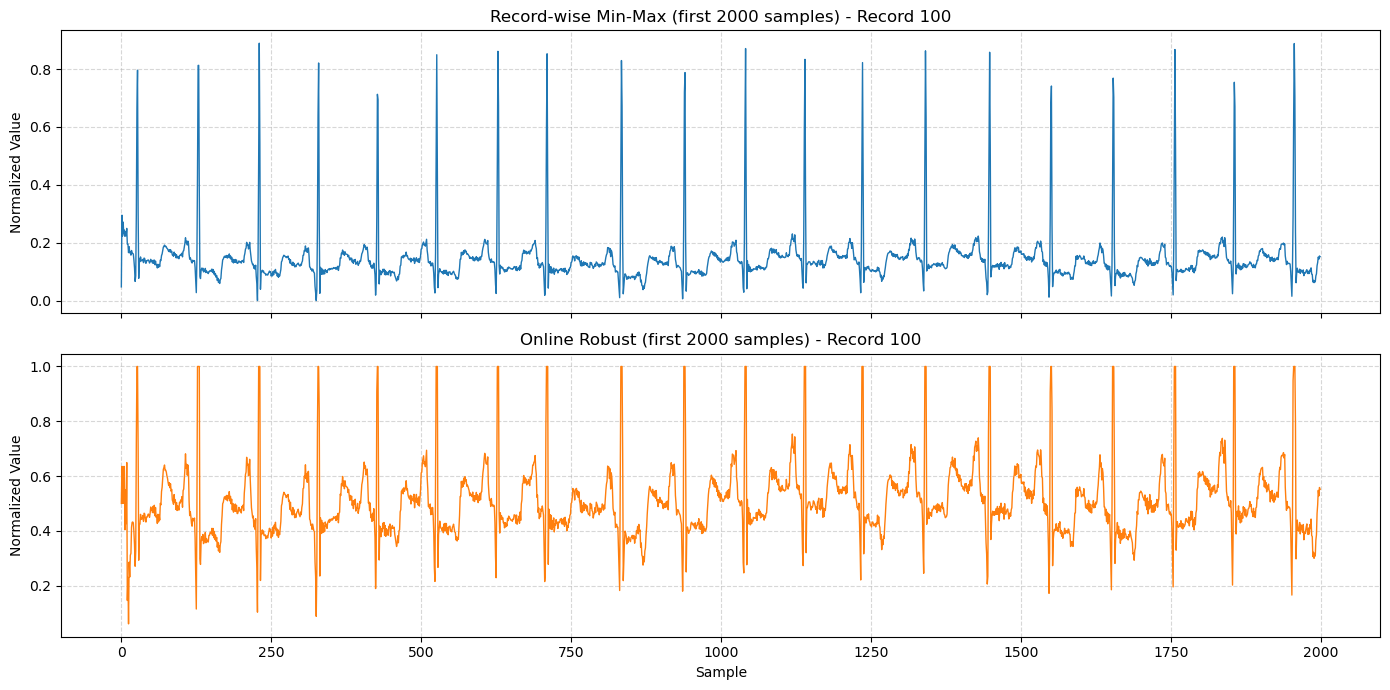

,mode,min,max,mean,std,q01,q99
0,record_minmax,0.0,1.0,0.154376,0.111210,0.015662,0.805674
1,online_robust,0.0,1.0,0.512291,0.130499,0.254117,1.000000


In [21]:
# Compare record-wise vs online normalization for one record (visual + quick stats)

# Pick a record to compare (change if needed)
compare_record_id = "100"

record_csv = os.path.join(signals_root, "record_minmax", f"{compare_record_id}_mlii_125hz_record.csv")
online_csv = os.path.join(signals_root, "online_robust", f"{compare_record_id}_mlii_125hz_online.csv")

if not os.path.exists(record_csv):
    raise FileNotFoundError(f"Record-normalized CSV not found: {record_csv}")
if not os.path.exists(online_csv):
    raise FileNotFoundError(f"Online-normalized CSV not found: {online_csv}")

df_record = pd.read_csv(record_csv)
df_online = pd.read_csv(online_csv)

n = min(len(df_record), len(df_online))
plot_samples = min(2000, n)

record_signal = df_record["MLII"].iloc[:plot_samples].to_numpy()
online_signal = df_online["MLII"].iloc[:plot_samples].to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(record_signal, color="tab:blue", linewidth=1.0)
axes[0].set_title(f"Record-wise Min-Max (first {plot_samples} samples) - Record {compare_record_id}")
axes[0].set_ylabel("Normalized Value")
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(online_signal, color="tab:orange", linewidth=1.0)
axes[1].set_title(f"Online Robust (first {plot_samples} samples) - Record {compare_record_id}")
axes[1].set_xlabel("Sample")
axes[1].set_ylabel("Normalized Value")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

stats_compare = pd.DataFrame([
    {
        "mode": "record_minmax",
        "min": float(df_record["MLII"].min()),
        "max": float(df_record["MLII"].max()),
        "mean": float(df_record["MLII"].mean()),
        "std": float(df_record["MLII"].std()),
        "q01": float(df_record["MLII"].quantile(0.01)),
        "q99": float(df_record["MLII"].quantile(0.99)),
    },
    {
        "mode": "online_robust",
        "min": float(df_online["MLII"].min()),
        "max": float(df_online["MLII"].max()),
        "mean": float(df_online["MLII"].mean()),
        "std": float(df_online["MLII"].std()),
        "q01": float(df_online["MLII"].quantile(0.01)),
        "q99": float(df_online["MLII"].quantile(0.99)),
    },
])

stats_compare